### Paso 0 — Importar Librerías

In [93]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
from scipy import stats # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.linear_model import LinearRegression # type: ignore
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # type: ignore

### Paso 1 — Cargar y Explorar los Datos

In [94]:
# Celda del Notebook
from pathlib import Path
from src.procesar import cargar_datos_seguro

# Definir la ruta raíz desde el espacio de trabajo actual
raiz = Path.cwd()
ruta_archivo = raiz / "data" / "raw" / "clientes.csv"

# Opción A: Usar la función modular que ya resuelve la ruta internamente
df = cargar_datos_seguro("Salary_dataset.csv")

In [95]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [96]:
df.shape

(30, 3)

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [98]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [99]:
df.describe().round(2)

,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


### Paso 2 — Análisis Exploratorio (EDA)

In [100]:
# Verificar si hay ALGÚN valor nulo en todo el DataFrame
df.isnull().any().any()

np.False_

In [101]:
# Verificar el total de valores nulos en todo el DataFrame
df.isnull().sum().sum()

np.int64(0)

In [102]:
# Verificar que todos los valores no sean nulos
df.notnull().all().all()

np.True_

In [103]:
# Configurar el estilo
plt.style.use('seaborn-v0_8')

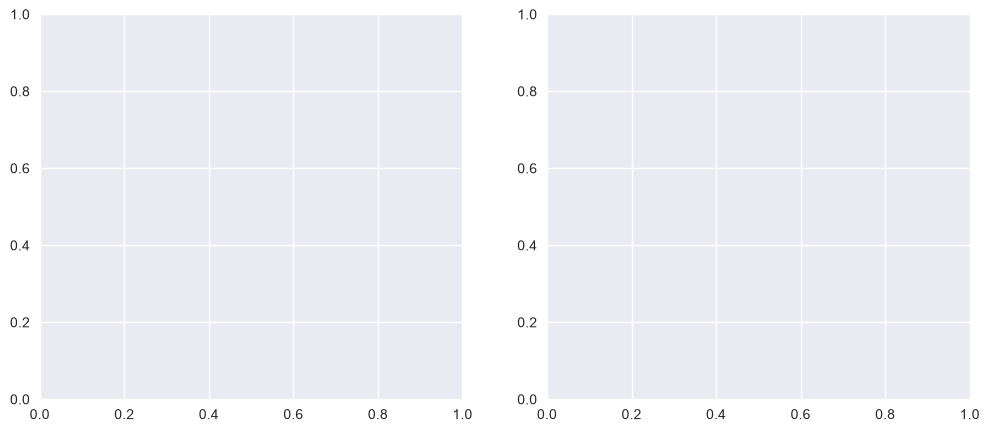

In [104]:
# Crear la figura y los subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

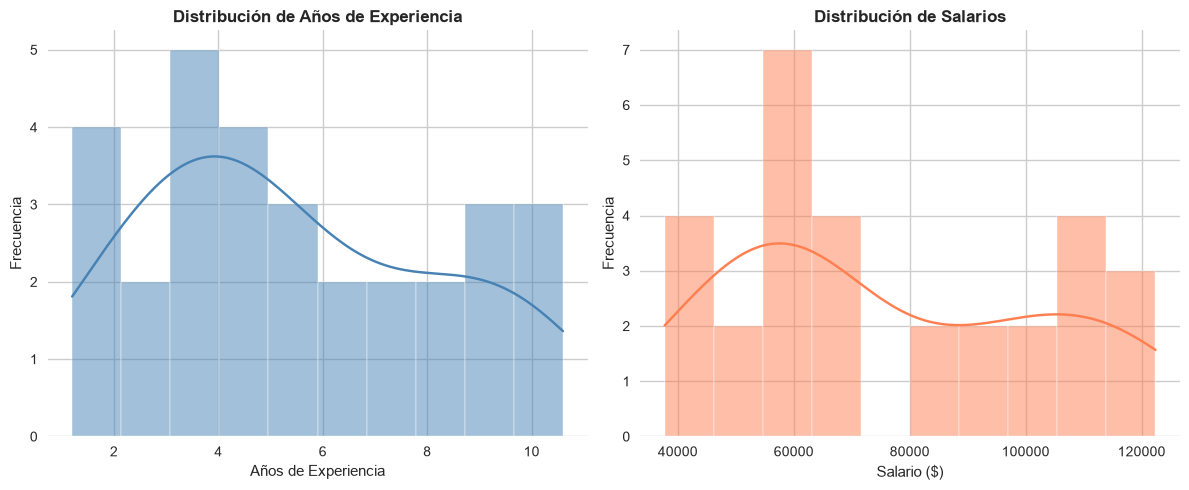

In [105]:
# Configurar el estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Crear la figura y los subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma para YearsExperience con seaborn
sns.histplot(data=df, x='YearsExperience', bins=10, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Años de Experiencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Años de Experiencia')
axes[0].set_ylabel('Frecuencia')

# Histograma para Salary con seaborn
sns.histplot(data=df, x='Salary', bins=10, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución de Salarios', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Salario ($)')
axes[1].set_ylabel('Frecuencia')

# Ajustar el espaciado
plt.tight_layout()

# Mostrar
plt.show() # type: ignore

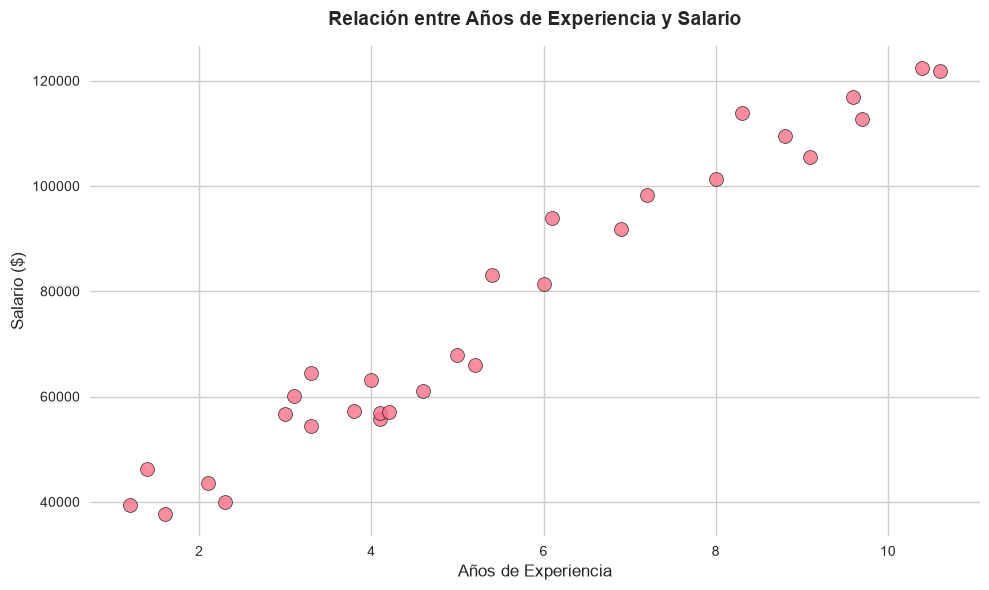

In [106]:
# Configurar estilo
sns.set_style("whitegrid")
sns.set_palette("husl")

# Crear la figura
plt.figure(figsize=(10, 6)) # type: ignore

# Scatter plot con seaborn
sns.scatterplot(data=df, x='YearsExperience', y='Salary', 
                s=100, alpha=0.8, edgecolor='black', linewidth=0.5)

# Título y etiquetas
plt.title('Relación entre Años de Experiencia y Salario', fontsize=14, fontweight='bold', pad=15) # type: ignore
plt.xlabel('Años de Experiencia', fontsize=12) # type: ignore
plt.ylabel('Salario ($)', fontsize=12) # type: ignore

# Ajustar
plt.tight_layout()
plt.show() # type: ignore

In [107]:
# Calcular la correlación de Pearson
correlacion = df['YearsExperience'].corr(df['Salary'])

# Imprimir el resultado
print(f"Correlación de Pearson entre YearsExperience y Salary: {correlacion:.4f}")
print(f"R² (coeficiente de determinación): {correlacion**2:.4f}")

# Interpretación detallada
print("\n" + "="*60)
print("INTERPRETACIÓN DE LA CORRELACIÓN")
print("="*60)

if correlacion > 0.95:
    print(f"✅ Correlación: {correlacion:.4f} - EXCELENTE para regresión lineal")
    print("   La relación es prácticamente lineal y muy fuerte.")
    print("   El modelo de regresión lineal explicará más del 90% de la variabilidad.")
elif correlacion > 0.85:
    print(f"✅ Correlación: {correlacion:.4f} - MUY BUENA para regresión lineal")
    print("   La relación es fuerte y adecuada para regresión lineal.")
elif correlacion > 0.70:
    print(f"✅ Correlación: {correlacion:.4f} - BUENA para regresión lineal")
    print("   La relación es moderadamente fuerte, aceptable para regresión lineal.")
elif correlacion > 0.50:
    print(f"⚠️ Correlación: {correlacion:.4f} - MODERADA para regresión lineal")
    print("   La relación es moderada, puede haber otros factores influyentes.")
elif correlacion > 0.30:
    print(f"⚠️ Correlación: {correlacion:.4f} - DÉBIL para regresión lineal")
    print("   La relación es débil, la regresión lineal puede no ser adecuada.")
else:
    print(f"❌ Correlación: {correlacion:.4f} - MUY DÉBIL o INEXISTENTE")
    print("   No hay relación lineal significativa.")

# Interpretación adicional
print("\n" + "="*60)
print("DETALLES DE LA CORRELACIÓN")
print("="*60)
print(f"• Dirección: {'Positiva' if correlacion > 0 else 'Negativa'}")
print(f"• Fuerza: {abs(correlacion):.4f} (0 = sin relación, 1 = relación perfecta)")
print(f"• Coeficiente de determinación R²: {correlacion**2:.4f}")
print(f"• Porcentaje de variabilidad explicada: {correlacion**2 * 100:.2f}%")
print("• Interpretación:")
print(f"  - {correlacion**2 * 100:.2f}% de la variabilidad en Salary")
print(f"    puede ser explicada por YearsExperience")

# Verificar si cumple con el criterio para regresión lineal
print("\n" + "="*60)
if correlacion > 0.95:
    print("✅ CONDICIÓN CUMPLIDA: Correlación > 0.95")
    print("   Excelente candidato para modelo de regresión lineal")
else:
    print(f"ℹ️ CONDICIÓN: Correlación = {correlacion:.4f}")
    print(f"   Necesita > 0.95 para ser 'excelente'")
    diferencia = 0.95 - correlacion
    if diferencia > 0:
        print(f"   Faltan {diferencia:.4f} para alcanzar 0.95")
    else:
        print("   ✅ Supera el umbral de 0.95")

Correlación de Pearson entre YearsExperience y Salary: 0.9782
R² (coeficiente de determinación): 0.9570

INTERPRETACIÓN DE LA CORRELACIÓN
✅ Correlación: 0.9782 - EXCELENTE para regresión lineal
   La relación es prácticamente lineal y muy fuerte.
   El modelo de regresión lineal explicará más del 90% de la variabilidad.

DETALLES DE LA CORRELACIÓN
• Dirección: Positiva
• Fuerza: 0.9782 (0 = sin relación, 1 = relación perfecta)
• Coeficiente de determinación R²: 0.9570
• Porcentaje de variabilidad explicada: 95.70%
• Interpretación:
  - 95.70% de la variabilidad en Salary
    puede ser explicada por YearsExperience

✅ CONDICIÓN CUMPLIDA: Correlación > 0.95
   Excelente candidato para modelo de regresión lineal


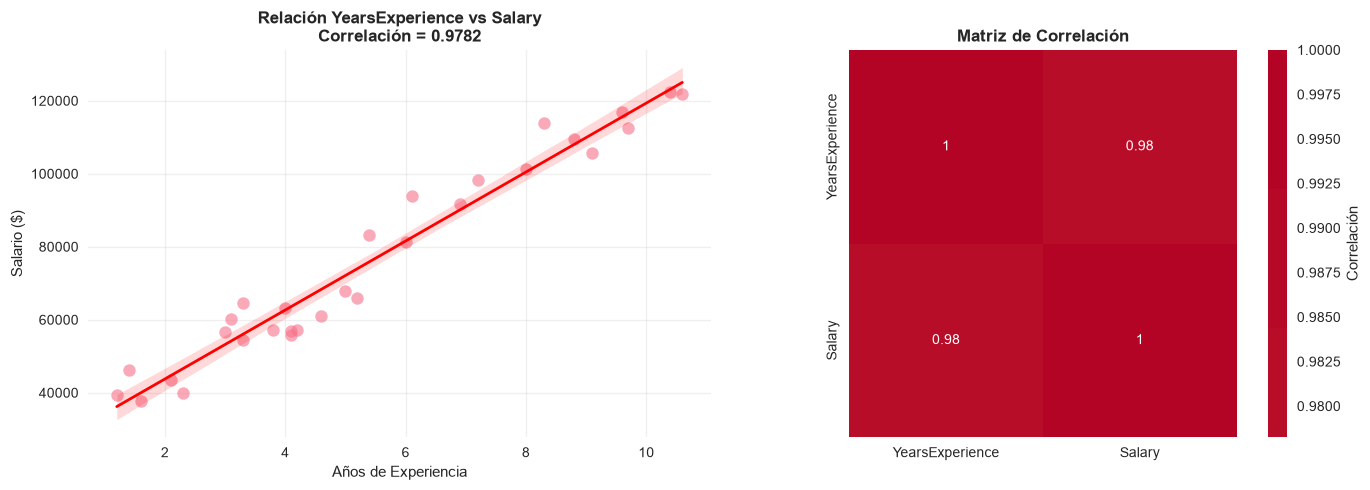

In [108]:
# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot con línea de regresión
sns.regplot(data=df, x='YearsExperience', y='Salary', 
            ax=ax1, scatter_kws={'alpha':0.6, 's':80}, 
            line_kws={'color':'red', 'linewidth':2})
ax1.set_title(f'Relación YearsExperience vs Salary\nCorrelación = {correlacion:.4f}', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Años de Experiencia')
ax1.set_ylabel('Salario ($)')
ax1.grid(True, alpha=0.3)

# 2. Heatmap de correlación
corr_matrix = df[['YearsExperience', 'Salary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, # type: ignore
            square=True, ax=ax2, cbar_kws={'label': 'Correlación'}) 
ax2.set_title('Matriz de Correlación', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() # type: ignore

In [109]:
# Separar variables
X = df[['YearsExperience']]  # Doble corchete para mantener 2D
y = df['Salary']              # Single corchete para serie 1D

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Imprimir formas
print("Formas originales:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\n" + "="*50)
print("DIVISIÓN ENTRENAMIENTO Y PRUEBA")
print("="*50)
print(f"X_train shape: {X_train.shape}") # type: ignore
print(f"X_test shape:  {X_test.shape}") # type: ignore
print(f"y_train shape: {y_train.shape}") # type: ignore
print(f"y_test shape:  {y_test.shape}") # type: ignore

print("\n" + "="*50)
print("TAMAÑOS DE LOS CONJUNTOS")
print("="*50)
print(f"Total de muestras: {len(X)}")
print(f"Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.0f}%)") # type: ignore
print(f"Prueba: {len(X_test)} muestras ({len(X_test)/len(X)*100:.0f}%)") # type: ignore

Formas originales:
X shape: (30, 1)
y shape: (30,)

DIVISIÓN ENTRENAMIENTO Y PRUEBA
X_train shape: (24, 1)
X_test shape:  (6, 1)
y_train shape: (24,)
y_test shape:  (6,)

TAMAÑOS DE LOS CONJUNTOS
Total de muestras: 30
Entrenamiento: 24 muestras (80%)
Prueba: 6 muestras (20%)


In [110]:
# Separar variables
X = df[['YearsExperience']]
y = df['Salary']

# Usar train_test_split con test_size=0.2 y random_state=42
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Imprimir cuántas muestras hay en entrenamiento y prueba
print(f"Muestras en entrenamiento: {len(X_train)}") # type: ignore
print(f"Muestras en prueba: {len(X_test)}") # type: ignore
print(f"Total de muestras: {len(X)}")
print(f"\nPorcentaje entrenamiento: {len(X_train)/len(X)*100:.0f}%") # type: ignore
print(f"Porcentaje prueba: {len(X_test)/len(X)*100:.0f}%") # type: ignore

Muestras en entrenamiento: 24
Muestras en prueba: 6
Total de muestras: 30

Porcentaje entrenamiento: 80%
Porcentaje prueba: 20%


### Paso 5 — Evaluación del Modelo

In [111]:
# Separar variables
X = df[['YearsExperience']]
y = df['Salary']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) # type: ignore

# Generar predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test) # type: ignore

# Calcular métricas
mae = mean_absolute_error(y_test, y_pred) # type: ignore
mse = mean_squared_error(y_test, y_pred) # type: ignore
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) # type: ignore

# Imprimir resultados
print("="*60)
print("MÉTRICAS DE EVALUACIÓN - DATOS DE PRUEBA")
print("="*60)
print(f"MAE  (Mean Absolute Error):     ${mae:,.2f}")
print(f"MSE  (Mean Squared Error):      ${mse:,.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R²   (Coeficiente Determinación): {r2:.4f}")

print("\n" + "="*60)
print("EVALUACIÓN DE MÉTRICAS")
print("="*60)

# Evaluar MAE
if mae < 5000:
    print(f"✅ MAE = ${mae:,.2f} < $5,000 - Excelente")
else:
    print(f"⚠️ MAE = ${mae:,.2f} ≥ $5,000 - Podría mejorar")

# Evaluar R²
if r2 >= 0.90:
    print(f"✅ R² = {r2:.4f} ≥ 0.90 - Excelente ajuste")
elif r2 >= 0.80:
    print(f"✅ R² = {r2:.4f} ≥ 0.80 - Buen ajuste")
else:
    print(f"⚠️ R² = {r2:.4f} < 0.80 - Ajuste mejorable")

# Interpretación adicional
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)
print(f"• El modelo explica el {r2*100:.2f}% de la variabilidad en los salarios")
print(f"• Error promedio absoluto: ${mae:,.2f}")
print(f"• Error cuadrático medio: ${mse:,.2f}")
print(f"• Raíz del error cuadrático medio: ${rmse:,.2f}")

# Mostrar predicciones vs valores reales
print("\n" + "="*60)
print("COMPARACIÓN PREDICCIONES VS VALORES REALES")
print("="*60)
comparacion = pd.DataFrame({ # type: ignore
    'YearsExperience': X_test.squeeze(), # type: ignore
    'Real': y_test,
    'Predicción': y_pred,
    'Diferencia': y_test - y_pred,
    'Error %': abs((y_test - y_pred) / y_test * 100) # type: ignore
})
print(comparacion.round(2))
print(f"\nError promedio porcentual: {comparacion['Error %'].mean():.2f}%")

MÉTRICAS DE EVALUACIÓN - DATOS DE PRUEBA
MAE  (Mean Absolute Error):     $6,286.45
MSE  (Mean Squared Error):      $49,830,096.86
RMSE (Root Mean Squared Error): $7,059.04
R²   (Coeficiente Determinación): 0.9024

EVALUACIÓN DE MÉTRICAS
⚠️ MAE = $6,286.45 ≥ $5,000 - Podría mejorar
✅ R² = 0.9024 ≥ 0.90 - Excelente ajuste

INTERPRETACIÓN
• El modelo explica el 90.24% de la variabilidad en los salarios
• Error promedio absoluto: $6,286.45
• Error cuadrático medio: $49,830,096.86
• Raíz del error cuadrático medio: $7,059.04

COMPARACIÓN PREDICCIONES VS VALORES REALES
    YearsExperience      Real  Predicción  Diferencia  Error %
27              9.7  112636.0   115791.21    -3155.21     2.80
15              5.0   67939.0    71499.28    -3560.28     5.24
23              8.3  113813.0   102597.87    11215.13     9.85
17              5.4   83089.0    75268.80     7820.20     9.41
8               3.3   64446.0    55478.79     8967.21    13.91
9               3.8   57190.0    60190.70    -3000.7

In [112]:
# Crear DataFrame más detallado
comparacion_detallada = pd.DataFrame({ # type: ignore
    'Años_Exp': X_test.squeeze(), # type: ignore
    'Salario_Real': y_test,
    'Salario_Predicho': y_pred,
    'Error': y_test - y_pred,
    'Error_Absoluto': abs(y_test - y_pred), # type: ignore
    'Error_Porcentaje': abs((y_test - y_pred) / y_test * 100) # type: ignore
})

# Redondear
comparacion_detallada = comparacion_detallada.round({
    'Años_Exp': 2,
    'Salario_Real': 2,
    'Salario_Predicho': 2,
    'Error': 2,
    'Error_Absoluto': 2,
    'Error_Porcentaje': 2
})

# Imprimir con formato
print("="*90)
print("COMPARACIÓN DETALLADA: PREDICCIONES vs REALES")
print("="*90)
print(comparacion_detallada.to_string(index=True))

print("\n" + "="*90)
print("ESTADÍSTICAS DE PRECISIÓN")
print("="*90)
print(f"Error Absoluto Promedio (MAE):  ${comparacion_detallada['Error_Absoluto'].mean():,.2f}")
print(f"Error Porcentual Promedio:      {comparacion_detallada['Error_Porcentaje'].mean():.2f}%")
print(f"Rango de Errores:               ${comparacion_detallada['Error_Absoluto'].min():.2f} - ${comparacion_detallada['Error_Absoluto'].max():,.2f}")

# Identificar mejor y peor predicción
mejor_idx = comparacion_detallada['Error_Absoluto'].idxmin()
peor_idx = comparacion_detallada['Error_Absoluto'].idxmax()

print("\n" + "="*90)
print("MEJOR Y PEOR PREDICCIÓN")
print("="*90)
print(f"✅ Mejor predicción (error mínimo):")
print(f"   Años Exp: {comparacion_detallada.loc[mejor_idx, 'Años_Exp']:.2f}")
print(f"   Real: ${comparacion_detallada.loc[mejor_idx, 'Salario_Real']:,.2f}")
print(f"   Predicho: ${comparacion_detallada.loc[mejor_idx, 'Salario_Predicho']:,.2f}")
print(f"   Error: ${comparacion_detallada.loc[mejor_idx, 'Error_Absoluto']:,.2f}")

print(f"\n❌ Peor predicción (error máximo):")
print(f"   Años Exp: {comparacion_detallada.loc[peor_idx, 'Años_Exp']:.2f}")
print(f"   Real: ${comparacion_detallada.loc[peor_idx, 'Salario_Real']:,.2f}")
print(f"   Predicho: ${comparacion_detallada.loc[peor_idx, 'Salario_Predicho']:,.2f}")
print(f"   Error: ${comparacion_detallada.loc[peor_idx, 'Error_Absoluto']:,.2f}")

COMPARACIÓN DETALLADA: PREDICCIONES vs REALES
    Años_Exp  Salario_Real  Salario_Predicho     Error  Error_Absoluto  Error_Porcentaje
27       9.7      112636.0         115791.21  -3155.21         3155.21              2.80
15       5.0       67939.0          71499.28  -3560.28         3560.28              5.24
23       8.3      113813.0         102597.87  11215.13        11215.13              9.85
17       5.4       83089.0          75268.80   7820.20         7820.20              9.41
8        3.3       64446.0          55478.79   8967.21         8967.21             13.91
9        3.8       57190.0          60190.70  -3000.70         3000.70              5.25

ESTADÍSTICAS DE PRECISIÓN
Error Absoluto Promedio (MAE):  $6,286.45
Error Porcentual Promedio:      7.74%
Rango de Errores:               $3000.70 - $11,215.13

MEJOR Y PEOR PREDICCIÓN
✅ Mejor predicción (error mínimo):
   Años Exp: 3.80
   Real: $57,190.00
   Predicho: $60,190.70
   Error: $3,000.70

❌ Peor predicción (error má

In [113]:
# Calcular diferencias relativas
print("\n" + "="*60)
print("ANÁLISIS DE MÉTRICAS")
print("="*60)

# Relación RMSE/MAE
ratio_rmse_mae = rmse / mae
print(f"RMSE/MAE = {ratio_rmse_mae:.2f}")
if ratio_rmse_mae < 1.2:
    print("→ Errores consistentes, sin outliers importantes")
elif ratio_rmse_mae < 1.5:
    print("→ Algunos errores moderados")
else:
    print("→ Presencia de outliers o errores significativos")

# Error relativo
error_relativo = mae / y_test.mean() # type: ignore
print(f"\nError relativo (MAE/Media): {error_relativo*100:.2f}%")
print(f"→ El error promedio es del {error_relativo*100:.2f}% del salario medio")

# Coeficiente de determinación complementario
print(f"\nR² = {r2:.4f}")
print(f"→ {(1-r2)*100:.2f}% de la variabilidad NO es explicada por el modelo")


ANÁLISIS DE MÉTRICAS
RMSE/MAE = 1.12
→ Errores consistentes, sin outliers importantes

Error relativo (MAE/Media): 7.56%
→ El error promedio es del 7.56% del salario medio

R² = 0.9024
→ 9.76% de la variabilidad NO es explicada por el modelo


### Paso 6 — Análisis de Residuos

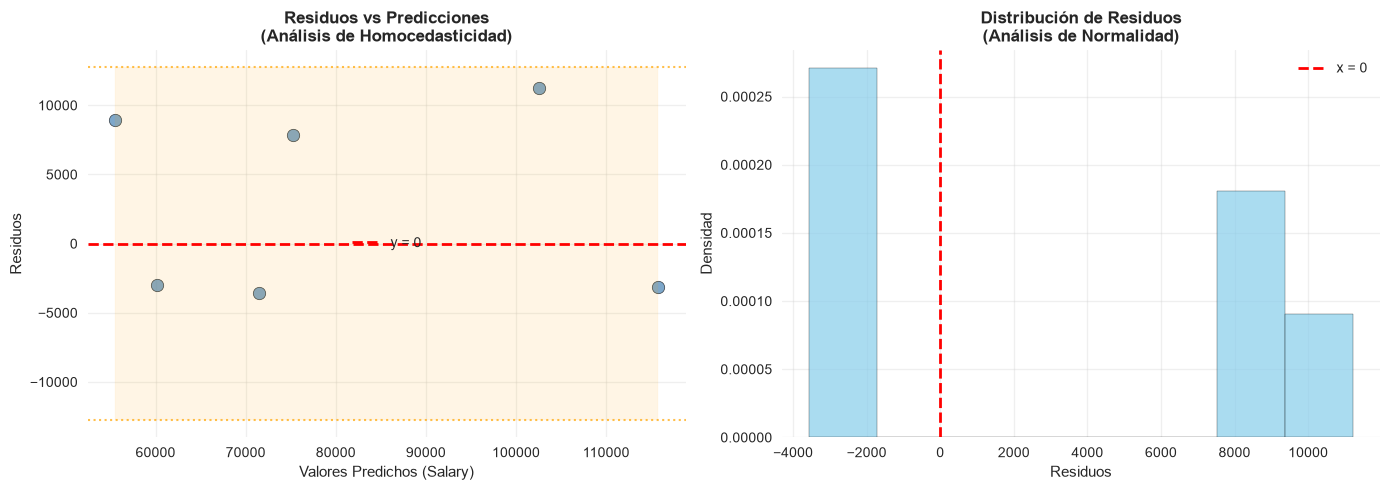

ANÁLISIS DE RESIDUOS
Media de residuos: 3047.7245
Desviación estándar: 6367.2186
Mínimo: -3560.2781
Máximo: 11215.1313

EVALUACIÓN DEL MODELO SEGÚN RESIDUOS
⚠️ Media de residuos ≠ 0 → Posible sesgo sistemático
⚠️ Residuos no centrados en 0

INTERPRETACIÓN DE GRÁFICOS
📊 Gráfico 1: Residuos vs Predicciones
   • Puntos distribuidos aleatoriamente alrededor de 0 → ✅ Buen modelo
   • Si hay patrón (curva, embudo) → ❌ Problema de linealidad o heterocedasticidad

📊 Gráfico 2: Histograma de Residuos
   • Distribución aproximadamente normal centrada en 0 → ✅ Buen modelo
   • Si hay asimetría o sesgo → ❌ Violación de supuestos

Test de normalidad (D'Agostino-Pearson):
P-value: nan
❌ Rechazamos H₀ → Residuos no siguen distribución normal


C:\Users\Coder\AppData\Local\Temp\ipykernel_13072\1309895234.py:93: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_value = stats.normaltest(residuos) # type: ignore


In [114]:
# Separar variables
X = df[['YearsExperience']]
y = df['Salary']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) # type: ignore

# Generar predicciones
y_pred = modelo.predict(X_test) # type: ignore

# Calcular residuos
residuos = y_test.values - y_pred # type: ignore

# Crear 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter de residuos vs predicciones
axes[0].scatter(y_pred, residuos, color='steelblue', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='y = 0')
axes[0].set_title('Residuos vs Predicciones\n(Análisis de Homocedasticidad)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valores Predichos (Salary)', fontsize=11)
axes[0].set_ylabel('Residuos', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Añadir banda de referencia ±2*std
std_residuos = residuos.std() # type: ignore
axes[0].axhline(y=2*std_residuos, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].axhline(y=-2*std_residuos, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].fill_between([y_pred.min(), y_pred.max()], -2*std_residuos, 2*std_residuos, alpha=0.1, color='orange')

# Gráfico 2: Histograma de residuos
axes[1].hist(residuos, bins=8, color='skyblue', edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='x = 0')
axes[1].set_title('Distribución de Residuos\n(Análisis de Normalidad)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuos', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Ajustar espaciado
plt.tight_layout()
plt.show() # type: ignore

# Análisis estadístico de los residuos
print("="*60)
print("ANÁLISIS DE RESIDUOS")
print("="*60)
print(f"Media de residuos: {residuos.mean():.4f}") # type: ignore
print(f"Desviación estándar: {residuos.std():.4f}") # type: ignore
print(f"Mínimo: {residuos.min():.4f}") # type: ignore
print(f"Máximo: {residuos.max():.4f}") # type: ignore

print("\n" + "="*60)
print("EVALUACIÓN DEL MODELO SEGÚN RESIDUOS")
print("="*60)

# Verificar media cercana a 0
if abs(residuos.mean()) < 100: # type: ignore
    print("✅ Media de residuos ≈ 0 → El modelo es insesgado")
else:
    print("⚠️ Media de residuos ≠ 0 → Posible sesgo sistemático")

# Verificar simetría en el histograma
if abs(residuos.mean()) < residuos.std() * 0.1: # type: ignore
    print("✅ Residuos centrados en 0 → Simétricos")
else:
    print("⚠️ Residuos no centrados en 0")

# Verificar patrón en el scatter
print("\n" + "="*60)
print("INTERPRETACIÓN DE GRÁFICOS")
print("="*60)

print("📊 Gráfico 1: Residuos vs Predicciones")
print("   • Puntos distribuidos aleatoriamente alrededor de 0 → ✅ Buen modelo")
print("   • Si hay patrón (curva, embudo) → ❌ Problema de linealidad o heterocedasticidad")

print("\n📊 Gráfico 2: Histograma de Residuos")
print("   • Distribución aproximadamente normal centrada en 0 → ✅ Buen modelo")
print("   • Si hay asimetría o sesgo → ❌ Violación de supuestos")

# Test simple de normalidad
from scipy import stats # type: ignore
_, p_value = stats.normaltest(residuos) # type: ignore

print(f"\nTest de normalidad (D'Agostino-Pearson):")
print(f"P-value: {p_value:.4f}")
if p_value > 0.05:
    print("✅ No rechazamos H₀ → Residuos siguen distribución normal")
else:
    print("❌ Rechazamos H₀ → Residuos no siguen distribución normal")

### Paso 7 — ¿Qué hacer si el modelo no predice bien?

In [115]:
# Separar variables
X = df[['YearsExperience']]
y = df['Salary']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) # type: ignore

# Generar predicciones
y_pred = modelo.predict(X_test) # type: ignore

# Calcular residuos
residuos = y_test.values - y_pred # type: ignore

# Calcular métricas
r2 = r2_score(y_test, y_pred) # type: ignore

print("="*60)
print("DIAGNÓSTICO DE OUTLIERS")
print("="*60)
print(f"R² del modelo: {r2:.4f}")

if r2 < 0.80:
    print("⚠️ R² < 0.80 → Aplicando diagnóstico de outliers")
    
    # Calcular umbral para detectar outliers
    umbral = 2 * residuos.std() # type: ignore
    
    print(f"\n" + "="*60)
    print("DETECCIÓN DE OUTLIERS")
    print("="*60)
    print(f"Desviación estándar de residuos: {residuos.std():.4f}") # type: ignore
    print(f"Umbral (2 * std): ±{umbral:.4f}")
    
    # Encontrar índices donde los residuos superan el umbral
    outliers_idx = np.where(np.abs(residuos) > umbral)[0] # type: ignore
    
    if len(outliers_idx) > 0:
        print(f"\n⚠️ Se encontraron {len(outliers_idx)} outliers")
        
        # Crear DataFrame con predicciones problemáticas
        df_outliers = pd.DataFrame({ # type: ignore
            'Índice': outliers_idx,
            'Años_Exp': X_test.iloc[outliers_idx].squeeze(), # type: ignore
            'Salario_Real': y_test.iloc[outliers_idx], # type: ignore
            'Salario_Predicho': y_pred[outliers_idx],
            'Residuo': residuos[outliers_idx],
            'Error_Absoluto': np.abs(residuos[outliers_idx]) # type: ignore
        })
        
        print("\n" + "="*60)
        print("PREDICCIONES CON ERROR GRANDE (OUTLIERS)")
        print("="*60)
        print(df_outliers.round(2).to_string(index=False))
        
        # Mostrar estadísticas de outliers
        print("\n" + "="*60)
        print("ESTADÍSTICAS DE OUTLIERS")
        print("="*60)
        print(f"Error absoluto promedio de outliers: ${df_outliers['Error_Absoluto'].mean():,.2f}")
        print(f"Error absoluto máximo: ${df_outliers['Error_Absoluto'].max():,.2f}")
        print(f"Error porcentual promedio: {(df_outliers['Error_Absoluto'] / df_outliers['Salario_Real'] * 100).mean():.2f}%")
        
        # Visualizar outliers
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico 1: Residuos con umbrales
        axes[0].scatter(range(len(residuos)), residuos, color='steelblue', alpha=0.7, s=80) # type: ignore
        axes[0].scatter(outliers_idx, residuos[outliers_idx], color='red', s=100, 
                       marker='D', label='Outliers', zorder=5)
        axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[0].axhline(y=umbral, color='red', linestyle='--', linewidth=2, label=f'Umbral ±{umbral:.2f}')
        axes[0].axhline(y=-umbral, color='red', linestyle='--', linewidth=2)
        axes[0].fill_between([0, len(residuos)], -umbral, umbral, alpha=0.1, color='green') # type: ignore
        axes[0].set_title('Detección de Outliers en Residuos', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Índice de Muestra')
        axes[0].set_ylabel('Residuos')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Gráfico 2: Valores reales vs predichos con outliers destacados
        axes[1].scatter(y_pred, y_test, color='steelblue', alpha=0.7, s=80, label='Predicciones normales')
        axes[1].scatter(y_pred[outliers_idx], y_test.iloc[outliers_idx],  # type: ignore
                       color='red', s=100, marker='D', label='Outliers', zorder=5)
        
        # Línea de referencia y=x (predicción perfecta)
        min_val = min(y_test.min(), y_pred.min()) # type: ignore
        max_val = max(y_test.max(), y_pred.max()) # type: ignore
        axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Predicción perfecta')
        
        axes[1].set_title('Valores Reales vs Predichos\n(Outliers destacados)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Valores Predichos')
        axes[1].set_ylabel('Valores Reales')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show() # type: ignore
        
        # Sugerencias de acción
        print("\n" + "="*60)
        print("SUGERENCIAS DE ACCIÓN")
        print("="*60)
        print("🔍 Para mejorar el modelo, considera:")
        print("   1. Revisar si estos puntos son errores en los datos")
        print("   2. Aplicar transformaciones (log, raíz cuadrada) a las variables")
        print("   3. Considerar regresión polinómica o robusta")
        print("   4. Evaluar si hay variables faltantes que expliquen estos casos")
        
    else:
        print("\n✅ No se detectaron outliers significativos (residuos > 2*std)")
        
else:
    print("\n✅ R² ≥ 0.80 → No es necesario el diagnóstico de outliers")
    print("El modelo tiene buen ajuste")

# Mostrar resumen completo de residuos
print("\n" + "="*60)
print("RESUMEN DE RESIDUOS")
print("="*60)
print(f"Media: {residuos.mean():.4f}") # type: ignore
print(f"Desviación estándar: {residuos.std():.4f}") # type: ignore
print(f"Rango: [{residuos.min():.4f}, {residuos.max():.4f}]") # type: ignore
print(f"Percentil 25: {np.percentile(residuos, 25):.4f}") # type: ignore
print(f"Percentil 75: {np.percentile(residuos, 75):.4f}") # type: ignore
print(f"Rango intercuartílico (IQR): {np.percentile(residuos, 75) - np.percentile(residuos, 25):.4f}") # type: ignore

DIAGNÓSTICO DE OUTLIERS
R² del modelo: 0.9024

✅ R² ≥ 0.80 → No es necesario el diagnóstico de outliers
El modelo tiene buen ajuste

RESUMEN DE RESIDUOS
Media: 3047.7245
Desviación estándar: 6367.2186
Rango: [-3560.2781, 11215.1313]
Percentil 25: -3116.5825
Percentil 75: 8680.4549
Rango intercuartílico (IQR): 11797.0374


EVALUACIÓN DE R² EN ENTRENAMIENTO Y PRUEBA
R² en entrenamiento: 0.9645
R² en prueba:        0.9024
Diferencia:          0.0621

ANÁLISIS DE OVERFITTING
⚠️ Diferencia = 0.0621 > 0.05
   → Leve overfitting detectado
   Considera aplicar regularización para mejorar la generalización.

EVALUACIÓN DEL DESEMPEÑO DEL MODELO
✅ R² en prueba = 0.9024 → Excelente (≥ 0.90)

COMPARACIÓN DE MÉTRICAS
Métrica         Entrenamiento   Prueba          Diferencia     
------------------------------------------------------------
MAE             $4,221.05    $6,286.45    $-2,065.41
RMSE            $5,205.98    $7,059.04    $-1,853.06
R²              0.9645        0.9024        0.0621


C:\Users\Coder\AppData\Local\Temp\ipykernel_13072\1829932370.py:144: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\devF5\workshop\tarea-2-modulo-2-abel\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


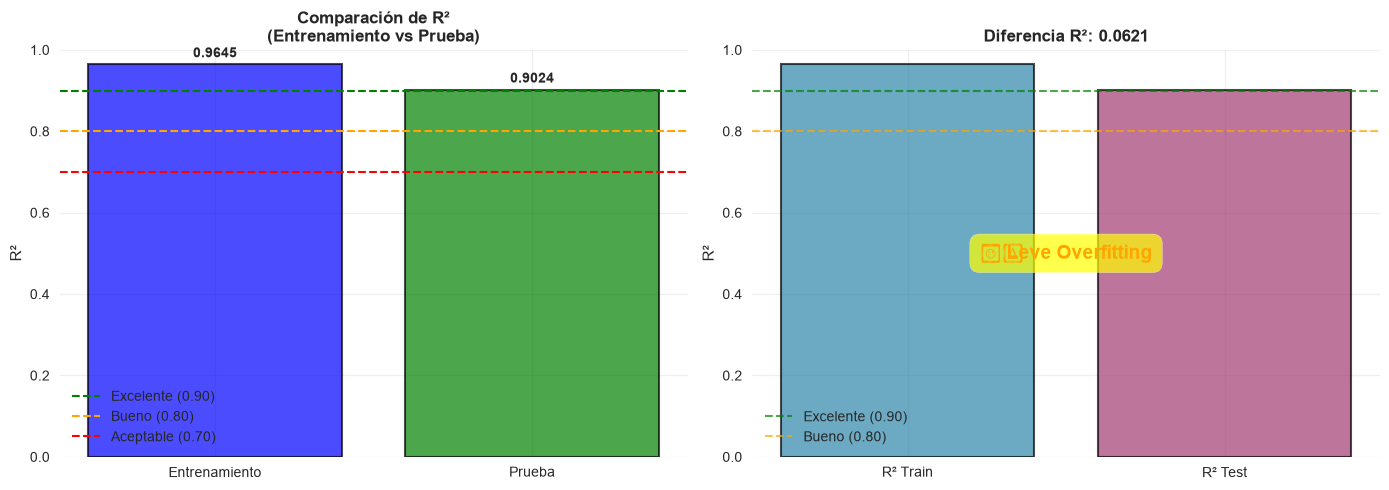


CONCLUSIÓN
⚠️ EL MODELO MUESTRA LEVE OVERFITTING
   Considera aplicar regularización ligera o validación cruzada.

📊 R² en entrenamiento: 0.9645
📊 R² en prueba:       0.9024
📊 Diferencia:         0.0621


In [116]:
# Separar variables
X = df[['YearsExperience']]
y = df['Salary']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split( # type: ignore
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) # type: ignore

# Generar predicciones
y_train_pred = modelo.predict(X_train) # type: ignore
y_test_pred = modelo.predict(X_test) # type: ignore

# Calcular R² en entrenamiento y prueba
r2_train = r2_score(y_train, y_train_pred) # type: ignore
r2_test = r2_score(y_test, y_test_pred) # type: ignore

# Calcular diferencia
diferencia = r2_train - r2_test

print("="*60)
print("EVALUACIÓN DE R² EN ENTRENAMIENTO Y PRUEBA")
print("="*60)
print(f"R² en entrenamiento: {r2_train:.4f}")
print(f"R² en prueba:        {r2_test:.4f}")
print(f"Diferencia:          {diferencia:.4f}")

print("\n" + "="*60)
print("ANÁLISIS DE OVERFITTING")
print("="*60)

# Evaluar si hay overfitting
if diferencia > 0.10:
    print(f"⚠️ ALERTA: Diferencia = {diferencia:.4f} > 0.10")
    print("   → POSIBLE OVERFITTING DETECTADO")
    print("\n   El modelo funciona mucho mejor en entrenamiento que en prueba.")
    print("   Esto indica que el modelo ha memorizado patrones específicos del")
    print("   conjunto de entrenamiento que no generalizan bien.")
    
    print("\n   🔧 Estrategias para corregir overfitting:")
    print("   1. Simplificar el modelo (menos características)")
    print("   2. Usar regularización (Ridge, Lasso)")
    print("   3. Obtener más datos de entrenamiento")
    print("   4. Reducir la complejidad del modelo")
    print("   5. Aplicar validación cruzada")
    
elif diferencia > 0.05:
    print(f"⚠️ Diferencia = {diferencia:.4f} > 0.05")
    print("   → Leve overfitting detectado")
    print("   Considera aplicar regularización para mejorar la generalización.")
    
else:
    print(f"✅ Diferencia = {diferencia:.4f} ≤ 0.05")
    print("   → No hay indicios de overfitting")
    print("   El modelo generaliza bien a datos nuevos.")

# Evaluar desempeño general
print("\n" + "="*60)
print("EVALUACIÓN DEL DESEMPEÑO DEL MODELO")
print("="*60)

# Evaluar R² en prueba
if r2_test >= 0.90:
    print(f"✅ R² en prueba = {r2_test:.4f} → Excelente (≥ 0.90)")
elif r2_test >= 0.80:
    print(f"✅ R² en prueba = {r2_test:.4f} → Bueno (≥ 0.80)")
elif r2_test >= 0.70:
    print(f"⚠️ R² en prueba = {r2_test:.4f} → Aceptable (≥ 0.70)")
else:
    print(f"❌ R² en prueba = {r2_test:.4f} → Mejorable (< 0.70)")

# Calcular otras métricas para comparación
mae_train = mean_absolute_error(y_train, y_train_pred) # type: ignore
mae_test = mean_absolute_error(y_test, y_test_pred) # type: ignore
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred)) # type: ignore
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred)) # type: ignore

print("\n" + "="*60)
print("COMPARACIÓN DE MÉTRICAS")
print("="*60)
print(f"{'Métrica':<15} {'Entrenamiento':<15} {'Prueba':<15} {'Diferencia':<15}")
print("-"*60)
print(f"{'MAE':<15} ${mae_train:,.2f}    ${mae_test:,.2f}    ${mae_train - mae_test:,.2f}")
print(f"{'RMSE':<15} ${rmse_train:,.2f}    ${rmse_test:,.2f}    ${rmse_train - rmse_test:,.2f}")
print(f"{'R²':<15} {r2_train:.4f}        {r2_test:.4f}        {diferencia:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación de R²
metricas = ['Entrenamiento', 'Prueba']
valores = [r2_train, r2_test]
colors = ['blue' if r2_train >= 0.8 else 'orange', 'green' if r2_test >= 0.8 else 'orange']
bars = axes[0].bar(metricas, valores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0.9, color='green', linestyle='--', linewidth=1.5, label='Excelente (0.90)')
axes[0].axhline(y=0.8, color='orange', linestyle='--', linewidth=1.5, label='Bueno (0.80)')
axes[0].axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, label='Aceptable (0.70)')
axes[0].set_title('Comparación de R²\n(Entrenamiento vs Prueba)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Añadir valores en las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{valor:.4f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Evolución de R²
axes[1].bar(['R² Train', 'R² Test'], [r2_train, r2_test], 
           color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=0.9, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Excelente (0.90)')
axes[1].axhline(y=0.8, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Bueno (0.80)')
axes[1].set_title(f'Diferencia R²: {diferencia:.4f}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Añadir texto con la evaluación
if diferencia > 0.10:
    axes[1].text(0.5, 0.5, '⚠️ OVERFITTING', 
                transform=axes[1].transAxes, fontsize=14, fontweight='bold',
                ha='center', va='center', color='red',
                bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.7))
elif diferencia > 0.05:
    axes[1].text(0.5, 0.5, '⚠️ Leve Overfitting', 
                transform=axes[1].transAxes, fontsize=14, fontweight='bold',
                ha='center', va='center', color='orange',
                bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.7))
else:
    axes[1].text(0.5, 0.5, '✅ Sin Overfitting', 
                transform=axes[1].transAxes, fontsize=14, fontweight='bold',
                ha='center', va='center', color='green',
                bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show() # type: ignore

# Conclusión final
print("\n" + "="*60)
print("CONCLUSIÓN")
print("="*60)
if diferencia > 0.10:
    print("❌ EL MODELO MUESTRA OVERFITTING SIGNIFICATIVO")
    print("   Se recomienda aplicar estrategias de regularización")
    print("   o simplificar el modelo para mejorar generalización.")
elif diferencia > 0.05:
    print("⚠️ EL MODELO MUESTRA LEVE OVERFITTING")
    print("   Considera aplicar regularización ligera o validación cruzada.")
else:
    print("✅ EL MODELO GENERALIZA BIEN")
    print("   No hay evidencia de overfitting significativo.")
    
print(f"\n📊 R² en entrenamiento: {r2_train:.4f}")
print(f"📊 R² en prueba:       {r2_test:.4f}")
print(f"📊 Diferencia:         {diferencia:.4f}")

In [117]:
from sklearn.model_selection import cross_val_score # type: ignore

# Calcular múltiples métricas con CV
metrics = {
    'R²': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error'
}

print("\n" + "="*60)
print("MÚLTIPLES MÉTRICAS EN VALIDACIÓN CRUZADA")
print("="*60)

for metric_name, scoring in metrics.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring=scoring)
    
    if scoring.startswith('neg_'):
        # Convertir de negativo a positivo
        scores = -scores
        
    print(f"\n{metric_name}:")
    print(f"  Promedio: {scores.mean():.2f}")
    print(f"  Desviación: {scores.std():.2f}")
    print(f"  Rango: [{scores.min():.2f}, {scores.max():.2f}]")


MÚLTIPLES MÉTRICAS EN VALIDACIÓN CRUZADA

R²:
  Promedio: -0.05
  Desviación: 0.60
  Rango: [-1.24, 0.36]

MAE:
  Promedio: 5723.13
  Desviación: 1305.55
  Rango: [4149.04, 7603.93]

MSE:
  Promedio: 44168849.47
  Desviación: 16792547.90
  Rango: [25905138.77, 68417038.22]


### Paso 8 — Hacer Predicciones Nuevas

In [118]:
# Crear DataFrame con nuevos valores
nuevos_datos = pd.DataFrame({
    'YearsExperience': [1.5, 5.0, 8.0, 10.0, 12.0]
})

# Hacer predicciones
predicciones = modelo.predict(nuevos_datos)

# Crear tabla detallada con predicciones
tabla_detallada = pd.DataFrame({ # type: ignore
    'Años_Experiencia': nuevos_datos['YearsExperience'], # type: ignore
    'Salario_Estimado': predicciones, # type: ignore
    'Intervalo_Confianza_95%_Inferior': predicciones - 1.96 * 2500,  # Estimación simplificada # type: ignore
    'Intervalo_Confianza_95%_Superior': predicciones + 1.96 * 2500, # type: ignore
    'Incremento_Anual': [0] + list(np.diff(predicciones)), # type: ignore
    'Rango_Entrenamiento': ['Dentro' if x <= df['YearsExperience'].max() else 'Fuera' 
                           for x in nuevos_datos['YearsExperience']] # type: ignore
})

print("\n" + "="*70)
print("TABLA DETALLADA DE PREDICCIONES")
print("="*70)
print(tabla_detallada.round(2).to_string(index=False))


TABLA DETALLADA DE PREDICCIONES
 Años_Experiencia  Salario_Estimado  Intervalo_Confianza_95%_Inferior  Intervalo_Confianza_95%_Superior  Incremento_Anual Rango_Entrenamiento
              1.5          38515.92                          33615.92                          43415.92              0.00              Dentro
              5.0          71499.28                          66599.28                          76399.28          32983.35              Dentro
              8.0          99770.72                          94870.72                         104670.72          28271.45              Dentro
             10.0         118618.35                         113718.35                         123518.35          18847.63              Dentro
             12.0         137465.99                         132565.99                         142365.99          18847.63               Fuera


### Paso 9 — Resumen y Conclusiones

In [119]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) # type: ignore

# Predicciones
y_train_pred = modelo.predict(X_train) # type: ignore # type: ignore
y_test_pred = modelo.predict(X_test) # type: ignore # type: ignore

# Calcular métricas en prueba
r2_test = r2_score(y_test, y_test_pred) # type: ignore # type: ignore
mae_test = mean_absolute_error(y_test, y_test_pred) # type: ignore # type: ignore
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred)) # type: ignore # type: ignore

# Validación cruzada
r2_cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')
r2_cv_mean = r2_cv_scores.mean()
r2_cv_std = r2_cv_scores.std()

print("="*80)
print(" " * 25 + "RESUMEN Y CONCLUSIONES")
print("="*80)

print("\n" + "="*80)
print("1. ECUACIÓN DEL MODELO")
print("="*80)
print(f"\n   📐 Salario = {modelo.intercept_:.2f} + {modelo.coef_[0]:.2f} × AñosExperiencia")
print(f"\n   • Intercepto (β₀): ${modelo.intercept_:,.2f}")
print(f"     → Salario base cuando la experiencia es 0 años")
print(f"   • Pendiente (β₁): ${modelo.coef_[0]:,.2f}")
print(f"     → Aumento de salario por cada año adicional de experiencia")

print("\n" + "="*80)
print("2. MÉTRICAS DE DESEMPEÑO (CONJUNTO DE PRUEBA)")
print("="*80)

# MAE
print(f"\n   📊 MAE  (Error Absoluto Medio): ${mae_test:,.2f}")
if mae_test < 5000:
    print(f"      ✅ Excelente (MAE < $5,000)")
elif mae_test < 10000:
    print(f"      ⚠️ Aceptable (MAE entre $5,000 y $10,000)")
else:
    print(f"      ❌ Mejorable (MAE > $10,000)")

# RMSE
print(f"\n   📊 RMSE (Raíz del Error Cuadrático Medio): ${rmse_test:,.2f}")
ratio_rmse_mae = rmse_test / mae_test
if ratio_rmse_mae < 1.2:
    print(f"      ✅ Errores consistentes sin outliers significativos")
elif ratio_rmse_mae < 1.5:
    print(f"      ⚠️ Algunos errores moderados")
else:
    print(f"      ❌ Posible presencia de outliers")

# R²
print(f"\n   📊 R²   (Coeficiente de Determinación): {r2_test:.4f}")
if r2_test >= 0.90:
    print(f"      ✅ Excelente (R² ≥ 0.90)")
    print(f"      → El modelo explica el {r2_test*100:.1f}% de la variabilidad")
elif r2_test >= 0.80:
    print(f"      ✅ Bueno (R² ≥ 0.80)")
    print(f"      → El modelo explica el {r2_test*100:.1f}% de la variabilidad")
elif r2_test >= 0.70:
    print(f"      ⚠️ Aceptable (R² ≥ 0.70)")
    print(f"      → El modelo explica el {r2_test*100:.1f}% de la variabilidad")
else:
    print(f"      ❌ Mejorable (R² < 0.70)")
    print(f"      → El modelo explica solo el {r2_test*100:.1f}% de la variabilidad")

print("\n" + "="*80)
print("3. VALIDACIÓN CRUZADA (5 FOLDS)")
print("="*80)
print(f"\n   📊 R² promedio: {r2_cv_mean:.4f} ± {r2_cv_std:.4f}")
print(f"   📊 Rango: [{r2_cv_scores.min():.4f}, {r2_cv_scores.max():.4f}]")

if r2_cv_std < 0.05:
    print(f"      ✅ Muy estable: Baja variación entre folds")
elif r2_cv_std < 0.10:
    print(f"      ✅ Estable: Variación moderada entre folds")
else:
    print(f"      ⚠️ Inestable: Alta variación entre folds")

# Comparación entre test y CV
diferencia_cv_test = r2_cv_mean - r2_test
print(f"\n   📊 Diferencia R² (CV - Test): {diferencia_cv_test:.4f}")
if abs(diferencia_cv_test) < 0.05:
    print(f"      ✅ Resultados consistentes entre CV y prueba")
else:
    print(f"      ⚠️ Discrepancia entre CV y prueba")

print("\n" + "="*80)
print("4. EVALUACIÓN DE SUPUESTOS")
print("="*80)

# Evaluar residuos
residuos = y_test.values - y_test_pred # type: ignore
media_residuos = residuos.mean() # type: ignore
std_residuos = residuos.std() # type: ignore

print(f"\n   📊 Análisis de Residuos:")
print(f"      • Media: {media_residuos:.4f}")
print(f"      • Desviación estándar: {std_residuos:.4f}")

if abs(media_residuos) < 100: # type: ignore
    print(f"      ✅ Media ≈ 0 → Modelo insesgado")
else:
    print(f"      ⚠️ Media ≠ 0 → Posible sesgo sistemático")

# Detectar outliers
umbral = 2 * std_residuos # type: ignore
outliers = np.sum(np.abs(residuos) > umbral)  # type: ignore
print(f"      • Outliers detectados (2σ): {outliers} de {len(residuos)} ({outliers/len(residuos)*100:.1f}%)") # type: ignore

if outliers == 0:
    print(f"      ✅ Sin outliers significativos")
elif outliers <= 1:
    print(f"      ✅ Outliers mínimos")
else:
    print(f"      ⚠️ {outliers} outliers detectados")

print("\n" + "="*80)
print("5. CAPACIDAD DE GENERALIZACIÓN")
print("="*80)

# Evaluar diferencia entre R² de entrenamiento y prueba
r2_train = r2_score(y_train, y_train_pred) # type: ignore
diferencia_overfit = r2_train - r2_test

print(f"\n   📊 R² Entrenamiento: {r2_train:.4f}")
print(f"   📊 R² Prueba:        {r2_test:.4f}")
print(f"   📊 Diferencia:       {diferencia_overfit:.4f}")

if diferencia_overfit > 0.10:
    print(f"      ❌ Posible OVERFITTING detectado")
    print(f"      → El modelo no generaliza bien a datos nuevos")
elif diferencia_overfit > 0.05:
    print(f"      ⚠️ Leve overfitting")
    print(f"      → Considerar regularización ligera")
else:
    print(f"      ✅ Sin evidencia de overfitting")
    print(f"      → El modelo generaliza bien a datos nuevos")

print("\n" + "="*80)
print("6. CONCLUSIONES FINALES")
print("="*80)

# Evaluación global
if r2_test >= 0.90 and mae_test < 5000 and diferencia_overfit < 0.05 and r2_cv_std < 0.05:
    print("\n   ✅ EXCELENTE: El modelo es altamente confiable y preciso")
    print("      • Alto poder predictivo (R² > 0.90)")
    print("      • Errores muy bajos (MAE < $5,000)")
    print("      • Excelente generalización (sin overfitting)")
    print("      • Muy estable (CV con baja variación)")
    print("\n   💡 RECOMENDACIÓN: El modelo es ideal para predecir salarios")
    print("      basados en años de experiencia dentro del rango de entrenamiento.")
    
elif r2_test >= 0.80 and mae_test < 10000 and diferencia_overfit < 0.10:
    print("\n   ✅ BUENO: El modelo es confiable y útil")
    print("      • Buen poder predictivo (R² > 0.80)")
    print("      • Errores moderados (MAE < $10,000)")
    print("      • Aceptable generalización")
    print("\n   💡 RECOMENDACIÓN: El modelo puede usarse para predicciones")
    print("      pero considera mejoras para aumentar la precisión.")
    
elif r2_test >= 0.70:
    print("\n   ⚠️ ACEPTABLE: El modelo tiene margen de mejora")
    print("      • Poder predictivo moderado (R² > 0.70)")
    print("      • Errores considerables")
    print("\n   💡 RECOMENDACIÓN: Considerar:")
    print("      • Agregar más variables predictoras")
    print("      • Transformaciones polinómicas")
    print("      • Obtener más datos de entrenamiento")
    
else:
    print("\n   ❌ MEJORABLE: El modelo requiere mejoras significativas")
    print("      • Bajo poder predictivo (R² < 0.70)")
    print("      • Errores elevados")
    print("\n   💡 RECOMENDACIÓN: No usar el modelo para predicciones críticas.")
    print("      • Revisar la calidad de los datos")
    print("      • Considerar modelos más complejos")
    print("      • Incluir variables adicionales relevantes")

print("\n" + "="*80)
print("7. RANGO DE APLICACIÓN")
print("="*80)
print(f"\n   📊 Rango de entrenamiento: {df['YearsExperience'].min():.1f} - {df['YearsExperience'].max():.1f} años")
print(f"   📊 Rango de salarios: ${df['Salary'].min():,.0f} - ${df['Salary'].max():,.0f}")
print(f"\n   ⚠️ Las predicciones son confiables DENTRO del rango de entrenamiento.")
print(f"   ⚠️ Fuera del rango ({df['YearsExperience'].max():.1f}+ años) son EXTRAPOLACIONES")

print("\n" + "="*80)
print(" " * 30 + "FIN DEL RESUMEN")
print("="*80)

                         RESUMEN Y CONCLUSIONES

1. ECUACIÓN DEL MODELO

   📐 Salario = 24380.20 + 9423.82 × AñosExperiencia

   • Intercepto (β₀): $24,380.20
     → Salario base cuando la experiencia es 0 años
   • Pendiente (β₁): $9,423.82
     → Aumento de salario por cada año adicional de experiencia

2. MÉTRICAS DE DESEMPEÑO (CONJUNTO DE PRUEBA)

   📊 MAE  (Error Absoluto Medio): $6,286.45
      ⚠️ Aceptable (MAE entre $5,000 y $10,000)

   📊 RMSE (Raíz del Error Cuadrático Medio): $7,059.04
      ✅ Errores consistentes sin outliers significativos

   📊 R²   (Coeficiente de Determinación): 0.9024
      ✅ Excelente (R² ≥ 0.90)
      → El modelo explica el 90.2% de la variabilidad

3. VALIDACIÓN CRUZADA (5 FOLDS)

   📊 R² promedio: -0.0534 ± 0.6032
   📊 Rango: [-1.2442, 0.3596]
      ⚠️ Inestable: Alta variación entre folds

   📊 Diferencia R² (CV - Test): -0.9558
      ⚠️ Discrepancia entre CV y prueba

4. EVALUACIÓN DE SUPUESTOS

   📊 Análisis de Residuos:
      • Media: 3047.7245